# Predictive Modeling Using Machine Learning

## Restaurant Cost Prediction Using Zomato Bangalore Dataset

**Author:** Poojan Javiya

This project focuses on building a machine learning regression model to predict restaurant pricing using restaurant-related features such as ratings, location, restaurant type, and ordering options.

## Loading the Cleaned Dataset

The cleaned dataset generated during the previous exploratory data analysis (EDA) task is loaded for machine learning modeling.

In [23]:
import pandas as pd

df = pd.read_csv('cleaned_zomato.csv')

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41263 entries, 0 to 41262
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         41263 non-null  str    
 1   online_order                 41263 non-null  str    
 2   book_table                   41263 non-null  str    
 3   rate                         41263 non-null  float64
 4   votes                        41263 non-null  int64  
 5   location                     41263 non-null  str    
 6   rest_type                    41263 non-null  str    
 7   cuisines                     41263 non-null  str    
 8   approx_cost(for two people)  41263 non-null  int64  
 9   menu_item                    41263 non-null  str    
 10  listed_in(type)              41263 non-null  str    
 11  listed_in(city)              41263 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 3.8 MB


In [25]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),menu_item,listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,[],Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,[],Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,[],Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,[],Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,[],Buffet,Banashankari


## Feature Selection

Relevant restaurant-related features were selected for training the regression model. These features include restaurant ratings, ordering options, restaurant categories, and location information.

The target variable for prediction is:

- `approx_cost(for two people)`

In [26]:
train = df.drop(columns=['name','menu_item','approx_cost(for two people)'])
test = df['approx_cost(for two people)']

In [27]:
train.head()

,online_order,book_table,rate,votes,location,rest_type,cuisines,listed_in(type),listed_in(city)
0,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",Buffet,Banashankari
1,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",Buffet,Banashankari
2,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",Buffet,Banashankari
3,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",Buffet,Banashankari
4,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",Buffet,Banashankari


In [28]:
train['location'].unique()

<StringArray>
[                 'Banashankari',                  'Basavanagudi',
                   'Mysore Road',                     'Jayanagar',
            'Kumaraswamy Layout',          'Rajarajeshwari Nagar',
                   'Vijay Nagar',                   'Uttarahalli',
                      'JP Nagar',               'South Bangalore',
                   'City Market',             'Bannerghatta Road',
                           'BTM',               'Kanakapura Road',
                  'Bommanahalli',               'Electronic City',
                 'Wilson Garden',                  'Shanti Nagar',
         'Koramangala 5th Block',                 'Richmond Road',
                           'HSR',         'Koramangala 7th Block',
                     'Bellandur',                 'Sarjapur Road',
                  'Marathahalli',                    'Whitefield',
                'East Bangalore',              'Old Airport Road',
                   'Indiranagar',         'Koram

In [29]:
train['rest_type'].unique()

<StringArray>
[                'Casual Dining',           'Cafe, Casual Dining',
                   'Quick Bites',           'Casual Dining, Cafe',
                          'Cafe',             'Quick Bites, Cafe',
             'Cafe, Quick Bites',                      'Delivery',
                          'Mess',                'Dessert Parlor',
        'Bakery, Dessert Parlor',                           'Pub',
                        'Bakery',            'Takeaway, Delivery',
                   'Fine Dining',                 'Beverage Shop',
                    'Sweet Shop',                           'Bar',
    'Dessert Parlor, Sweet Shop',           'Bakery, Quick Bites',
       'Sweet Shop, Quick Bites',                         'Kiosk',
                    'Food Truck',   'Quick Bites, Dessert Parlor',
    'Beverage Shop, Quick Bites', 'Beverage Shop, Dessert Parlor',
                      'Takeaway',            'Pub, Casual Dining',
            'Casual Dining, Bar', 'Dessert Parlo

In [30]:
train['cuisines'].unique()

<StringArray>
[                                              'North Indian, Mughlai, Chinese',
                                                  'Chinese, North Indian, Thai',
                                                       'Cafe, Mexican, Italian',
                                                   'South Indian, North Indian',
                                                     'North Indian, Rajasthani',
                                                                 'North Indian',
                                  'North Indian, South Indian, Andhra, Chinese',
                                                         'Pizza, Cafe, Italian',
                                                   'Cafe, Italian, Continental',
                                     'Cafe, Mexican, Italian, Momos, Beverages',
 ...
 'Continental, Mediterranean, Italian, North Indian, Finger Food, Asian, Momos',
                                                                'Mediterranean',
         

In [31]:
train['listed_in(city)'].unique()

<StringArray>
[         'Banashankari',     'Bannerghatta Road',          'Basavanagudi',
             'Bellandur',          'Brigade Road',           'Brookefield',
                   'BTM',         'Church Street',       'Electronic City',
           'Frazer Town',                   'HSR',           'Indiranagar',
             'Jayanagar',              'JP Nagar',          'Kalyan Nagar',
          'Kammanahalli', 'Koramangala 4th Block', 'Koramangala 5th Block',
 'Koramangala 6th Block', 'Koramangala 7th Block',          'Lavelle Road',
          'Malleshwaram',          'Marathahalli',               'MG Road',
          'New BEL Road',      'Old Airport Road',           'Rajajinagar',
        'Residency Road',         'Sarjapur Road',            'Whitefield']
Length: 30, dtype: str

In [32]:
train['listed_in(type)'].unique()

<StringArray>
[            'Buffet',              'Cafes',           'Delivery',
           'Desserts',           'Dine-out', 'Drinks & nightlife',
      'Pubs and bars']
Length: 7, dtype: str

In [37]:
train = train.drop(columns=['cuisines'])

## Feature Encoding

Machine learning models require numerical input data. Categorical features such as restaurant type and location were converted into numerical format using one-hot encoding with `pd.get_dummies()`.

The `cuisines` column was excluded due to extremely high categorical complexity.

In [39]:
train = pd.get_dummies(train, drop_first=True)

In [40]:
train.shape

(41263, 216)

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Train-Test Split

The dataset was divided into training and testing sets using an 80-20 split. This allows the model to be trained on one portion of the data and evaluated on unseen data.

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    train, test, train_size=0.8, random_state=42
)

In [48]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [49]:

y_pred = model.predict(X_test)

## Model Evaluation

The trained model was evaluated using standard regression metrics including:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help measure the accuracy and predictive capability of the regression model.

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

In [51]:
print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("Root Mean Squared Error:", rmse)

print("R² Score:", r2)

Mean Absolute Error: 149.09416195876614
Mean Squared Error: 48872.44602729995
Root Mean Squared Error: 221.07113341026673
R² Score: 0.7737740934981628


## Actual vs Predicted Restaurant Cost

The scatter plot below compares actual restaurant costs with model predictions. A strong positive trend indicates that the model successfully learned meaningful relationships between restaurant features and pricing.

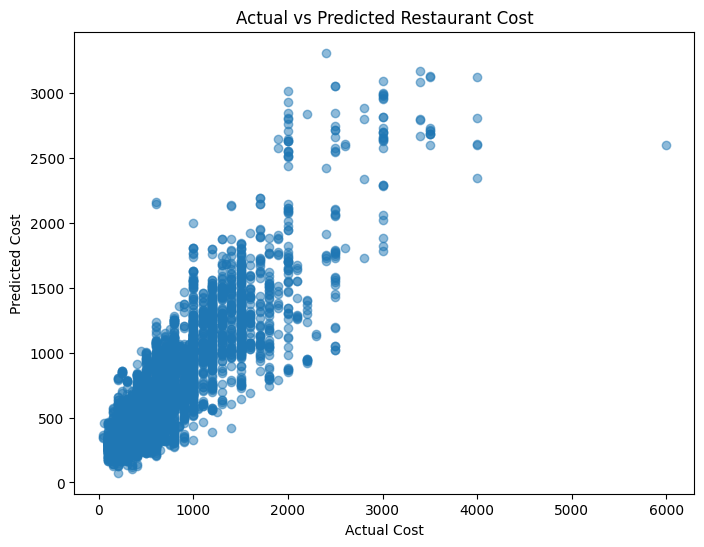

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")

plt.title("Actual vs Predicted Restaurant Cost")

plt.show()

## Conclusion

This project successfully implemented a machine learning regression workflow for restaurant cost prediction using the Zomato Bangalore dataset.

The Linear Regression model achieved strong predictive performance with an R² score of approximately 0.77, indicating that restaurant features such as ratings, location, and restaurant type are strongly associated with pricing.

The project demonstrated practical applications of:
- Data preprocessing
- Feature engineering
- Regression modeling
- Model evaluation
- Predictive analytics